In [1]:
#@title Install Dependencies
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !pip install -q gymnasium
    !pip install moviepy
    !apt install ffmpeg
    !pip install imageio-ffmpeg
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

bash: ../xvfb: No such file or directory


# OpenAI Gym

OpenAI Gym, often referred to as "Gym", is a toolkit for developing and comparing RL algorithms. Gym provides a collection of environments with a standardized interface, making it easy for researchers and developers to experiment with and evaluate different RL algorithms. These environments cover a wide range of tasks, from simple toy problems to complex simulations and they allow users to develop and test their RL agents without having to implement the environment themselves. The toolkit is widely used in the field of ML and RL for experimentation and benchmarking purposes.

# Classic Control Environments

CartPole is part of [Classic Control Environments](https://www.gymlibrary.dev/environments/classic_control/), which include five classic control environments, i.e. Acrobot, CartPole, Mountain Car, Continuous Mountain Car, and Pendulum. You can access that first link for general information. Among Gym environments, this set of environments is among the easiest to be solved by a policy.  

# CartPole Environment

This environment corresponds to the version of Michie and Chambers' pole balancing problem, e.g. [Barto, Sutton, and Anderson (1983)](https://ieeexplore.ieee.org/document/6313077)

In [2]:
from IPython.display import HTML

gif_url = 'https://www.gymlibrary.dev/_images/cart_pole.gif'

html_code = f'<img src="{gif_url}" alt="Your GIF">'

HTML(html_code)

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright in the track and the goal is to balance the pole by applying forces in the left and right directions on the cart. The action is an `ndarray` with shape `(1, )` which can take values `{0,1}` indicating the direction of the fixed force the cart is pushed, with `0` indicating a push to the left and `1` indicating a push to the right. The state space is an `ndarray` with shape `(4, )` with the values corresponding to the following positions and velocities:


0.   Cart Position
1.   Cart Velocity
2.   Pole Angle
3.   Pole Angular Velocity

Since our goal is to keep the pole upright for as long as possible, a reward of `+1` is received for each step taken, including the termination step.

Please refer to [official documention](https://www.gymlibrary.dev/environments/classic_control/cart_pole/) for the ranges that denote the possible values for the state space coordinates listed above. Despite those, an episode terminates if Cart Position (index 0) falls out of the `(-2.4, 2.4)` range. Also, an episode terminates if Pole Angular Velocity (index 4) is not in the range of $\pm 12^{\circ}$. The threshold for received rewards is `475`, which means that the environment CartPole-v1 considers an episode as "solved" if the total cumulative reward exceeds or equals `475`. Reaching an average reward per episode above this threshold indicates that the agent is performing well and has learned a suitable policy for pole-balancing. If the episode length is greater than `500`, an episode ends too.

In [6]:
!pip install gymnasium
!pip install matplotlib


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 17.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 19.3 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 23.8 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# also you need to install ffmpeg if not installed
# for MacOS: ! brew install ffmpeg

In [ ]:
! brew install ffmpeg

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:cef6f881f516d2cdbd0a5bfc7e20318da8b047cf2674ee27c5d4858d3ecd6430
######################################################################### 100.0%
==> Pouring portable-ruby-4.0.1.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
actions-up: Tool to update GitHub Actions to latest versions with SHA pinning
adplay: Command-line player for OPL2 music
agent-browser: Browser automation CLI for AI agents
any2fasta: Convert various sequence formats to FASTA
aoe: Terminal session manager for AI coding agents
apache-arrow-adbc: Cross-language, Arrow-native database access
apache-serf: High-performance asynchronous HTTP client library
apkeep: Comman

By running the cell below we create a gym environment for the CartPole-v1 task, we initialize the environment and obtain an initial state. Moreover, we retrieve the number of available actions and the dimension of the state space. Finally, we display the initial rendering of the CartPole-v1 environment. After the `print()` statements are displayed, notice that the action space and state space dimensions are in accordance with those described above and in the official documentation. Also, observe that the initial state has coordinates that all lie between `(-0.05, 0.05)`, which is also in accordance with official documentation as all state space coordinates are assigned a uniformly chosen random value from the aforementioned interval.

Initial State: (array([ 0.00407941, -0.0203073 , -0.0385482 ,  0.04076459], dtype=float32), {})
Action Space Dimension: 2
State Space Dimension: (4,)


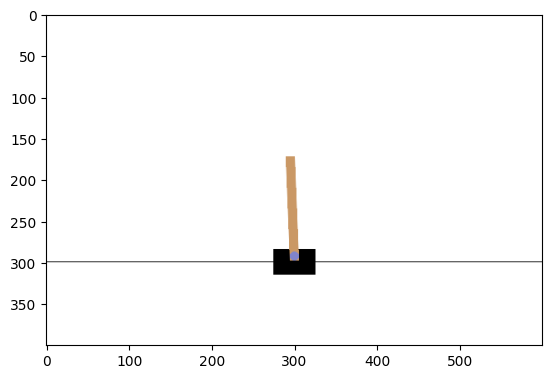

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

# gym compatibility: unwrap TimeLimit
if hasattr(env, '_max_episode_steps'):
    env = env.env

# initialize the environment and obtain the initial state
env.reset()
print("Initial State:", env.reset())

n_actions = env.action_space.n
print("Action Space Dimension:", n_actions)

state_dim = env.observation_space.shape
print("State Space Dimension:", state_dim)

plt.imshow(env.render())

# Build the Policy Network for REINFORCE

In this section, your task is to build a neural network, the policy network, that will predict action probabilities given states. Fill the **< YOUR CODE HERE >** below with your preferred NN architecture. You can refrain from using a deep NN as CartPole-v1 is not worth of deep NN architectures. A shallow NN of one or two hidden layers will be just fine!
> Write an `__init__(...)` function that initializes the network with the given state dimensions and desired output dimensions.

> Write the `forward(...)` function that performs the forward pass of the network

> Write a `get_action(...)` function that takes a batch of states as inputs and uses the policy network to predict action probabilities for each state. Follow those steps in order:
  *   Convert states to PyTorch tensors.
  *   Forward pass through the model to produce logits. Hint: Ensure that the calculation is done without gradient tracking, as it is typically done during inference rather than training. You can stop gradient storing with decorator `@torch.no_grad()`.
  *   Apply softmax to get action probabilities.
  *   Return the resulting action probabilities after converting them back to a NumPy array.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the neural network for policy
class MLP(nn.Module):
  < YOUR CODE HERE >

Next, instantiate the policy network model

In [ ]:
# instantiate the policy network model
model = < YOUR CODE HERE >

After writting your `get_action(...)` function run the cell below to test it.

In [ ]:
test_states = np.array([env.reset()[0] for _ in range(5)])
test_probas = model.get_action(test_states)
assert isinstance(test_probas, np.ndarray), \
    "you must return np array and not %s" % type(test_probas)
assert tuple(test_probas.shape) == (test_states.shape[0], env.action_space.n), \
    "wrong output shape: %s" % np.shape(test_probas)
assert np.allclose(np.sum(test_probas, axis=1), 1), "probabilities do not sum to 1"
print("all good!")

# Use the policy network to obtain an episode

Here is a summary of what your code should do:


*   Initialize empty lists of states, actions and rewards to record the trajectory of the episode.
*   Reset the environment and obtain an initial state.
*   Loop over time steps to obtain the episode within a specified maximum number of steps.
> *   Obtain the action probabilities given the current state and the policy network.
> *   Sample an action **from the action probabilities** using `np.random.choice`.
> *   Take a step in the environment with the chosen action and obtain the new state, immediate reward, termination status, truncation status, and additional information. For the meaning of the latter three, please refer to official [Gymnasium Documentation](https://gymnasium.farama.org/api/env/).
> *   Record the current state, action, and reward in the corresponding lists.
> *   Update the current state to the new state.
> *   If the episode is terminated or truncated, exit the loop.
> *   Return the recorded lists of states, actions and rewards for later use.





In [ ]:
def rollout_fn(env, model, t_max=500):
    """
    Obtain an episode with REINFORCE agent.
    Returns sequences of states, actions, and rewards.
    """
    < YOUR CODE HERE >
    return < YOUR CODE HERE >

In the snippet below you can test your function. You can also include some print statements in order to realize the length of a full episode, as well as the specific trajectory of states, actions, and rewards that was played out.

In [ ]:
# test it
states, actions, rewards = rollout_fn(env, model)

# Compute returns-to-go

Now, you have to implement a function that returns a list of returns-to-go, where each entry of the list represents the total (discounted) reward you have accumulated up to that time-step in the episode. The prodecure is quite standard although we give some more details below.

In [ ]:
def get_returns_to_go(rewards,  # rewards at each step
                      gamma=0.99, # discount for reward
                      normalize=False):
    """
    Take a list of immediate rewards for the whole episode
    and compute returns-to-go

    A simple way to compute returns-to-go is to iterate from the last to the first time-step and compute recurrently

    In some applications returns are normalized by subtracting their mean and dividing by their standard deviation. For this purpose we included the boolean normalize as an arg

    You must return an array/list of returns-to-go with as many elements as in the initial rewards.
    """
    < YOUR CODE HERE >

    return < YOUR CODE HERE >

After your implementation execute the code in the following cell and make sure that the statement "looks good" is displayed.

In [ ]:
get_returns_to_go(rewards)
assert len(get_returns_to_go(list(range(100)))) == 100
assert np.allclose(
    get_returns_to_go([0, 0, 1, 0, 0, 1, 0], gamma=0.9),
    [1.40049, 1.5561, 1.729, 0.81, 0.9, 1.0, 0.0])
assert np.allclose(
    get_returns_to_go([0, 0, 1, -2, 3, -4, 0], gamma=0.5),
    [0.0625, 0.125, 0.25, -1.5, 1.0, -4.0, 0.0])
assert np.allclose(
    get_returns_to_go([0, 0, 1, 2, 3, 4, 0], gamma=0),
    [0, 0, 1, 2, 3, 4, 0])
print("looks good!")

# Objective function and updates over the policy gradient

The policy gradient theorem defines a way to compute the gradient of the objective function with respect to the parameters of the policy network as follows:
$$
\nabla_{\theta} J(\theta)\approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=1}^T G_t^{(i)} \nabla_{\theta} \log \pi_{\theta} (a_t^{(i)}|s_t^{(i)}).
$$
for $N$ episodic trajectories $(\tau^{(i)})_{i=1}^{N}:=\{(s_0^{(i)}, a_0^{(i)}, r_1^{(i)}, s_1^{(i)}, a_1^{(i)}, r_2^{(i)}, ..., s_{T-1}^{(i)}, a_{T-1}^{(i)}, r_{T}^{(i)})\}_{i=1}^{N}$, and corresponding returns-to-go $G_t^{(i)}$.

In the cell below your task is to define the training process of the policy gradient algorithm. Breaking the process down:

*   Optimizer initialization: Initialize an Adam optimizer to update the parameters of the policy network (choose a learning of `1e-03`) and leave all the other Adam parameters as default.
*   Cast states, actions into PyTorch tensors (states take float values, actions take integer values).
*   Use the `get_returns_to_go(...)` function to compute returns-to-go and cast into PyTorch tensors.
*   Use the policy network to predict logits, action probabilities and log-action probabilities. Compute those using operations with torch tensors and **DO NOT** use the `get_action(...)` function instead.
*   Select log-action probabilities for chosen actions.
*   Compute the loss.
*   Perform gradient ascent to update the policy network's parameters.
*   Return the sum of rewards obtained during the duration of an episode.



In [ ]:
# define optimizer
optimizer = < YOUR CODE HERE >

def train_step(states, actions, rewards, gamma=0.99):
    """
    Takes a sequence of states, actions and rewards produced by rollout_fn.
    Updates agent's weights by following the policy gradient above.
    """
    < YOUR CODE HERE >

    return <YOUR CODE HERE >

# Training and recording the performance

Plot the training curve averaged over three runs (3 seeds). Each run has a training and a testing phase. As a suggestion, for this lab, you might want to try the following:


1.   **Training Phase**: set the model in training mode using `model.train()`.
2.   The agent interacts with the environment for 1000 training episodes, collecting rewards during each episode. During each training episode the model is updated using the policy gradient algorithm implemented on the `train_step(...)` function. Training rewards are collected in a list.
3.   **Testing Phase**: Every 100 episodes the model is switched to evaluation mode using `model.eval()`. At this stage, the agent interacts with the environment for 50 episodes, uses a deterministic strategy by selecting the action with the highest probability, and stores an average of the rewards collected over them.
4.   After the testing phase finishes, the model is switched on to training mode again.



In [ ]:
def train_iteration(< YOUR CODE HERE >):
  < YOUR CODE HERE >

# BONUS

Modify policy gradient in creative ways to improve its performance. Some things you can try are adding entropy bonus, modifying hyper parameters, normalizing returns-to-go and advantages, etc.

Please clearly report/document the changes made and expected/observed results.

In [ ]:
def entropy_reg(probs, log_probs, entropy_coef=1e-02):
  """
  Takes tensors of probabilities and corresponding log-probabilities and returns the entropy multiplied by entropy_coef
  """
  return -entropy_coef * torch.sum(probs * log_probs)